# RUL-Prediction

## Dataset Overview & Initial Inspection

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import joblib
import os

rul_df = pd.read_csv("../data/RUL_FD004.txt", sep = r"\s+", header=None)
train_df = pd.read_csv("../data/train_FD004.txt", sep=r"\s+", header=None)
test_df = pd.read_csv("../data/test_FD004.txt", sep=r"\s+", header=None)

In [3]:
import random
import numpy as np

SEED = 42
random.seed(SEED)

rng = np.random.default_rng(SEED)

In [4]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')
warnings.filterwarnings('ignore', category=FutureWarning, module='numpy')

In [5]:
columns = (
    ["engine_id", "cycle"]
    + [f"op_setting_{i}" for i in range(1, 4)]
    + [f"sensor_{i}" for i in range(1, 22)]
)

train_df.columns = columns
test_df.columns = columns

rul_df.columns = ["RUL"]

In [6]:
num_train_engines = train_df["engine_id"].nunique()
num_test_engines = test_df["engine_id"].nunique()

print(f"Training engines: {num_train_engines}")
print(f"Testing engines: {num_test_engines}")

Training engines: 249
Testing engines: 248


In [7]:
engine_lifetimes = (
    train_df.groupby("engine_id")["cycle"]
    .max()
)

min_lifetime = engine_lifetimes.min()
max_lifetime = engine_lifetimes.max()
avg_lifetime = engine_lifetimes.mean()

print(f"Minimum lifetime: {min_lifetime}")
print(f"Maximum lifetime: {max_lifetime}")
print(f"Average lifetime: {avg_lifetime:.2f}")

Minimum lifetime: 128
Maximum lifetime: 543
Average lifetime: 245.98


In [8]:
print(engine_lifetimes.describe())

count    249.00000
mean     245.97992
std       73.11080
min      128.00000
25%      190.00000
50%      234.00000
75%      290.00000
max      543.00000
Name: cycle, dtype: float64


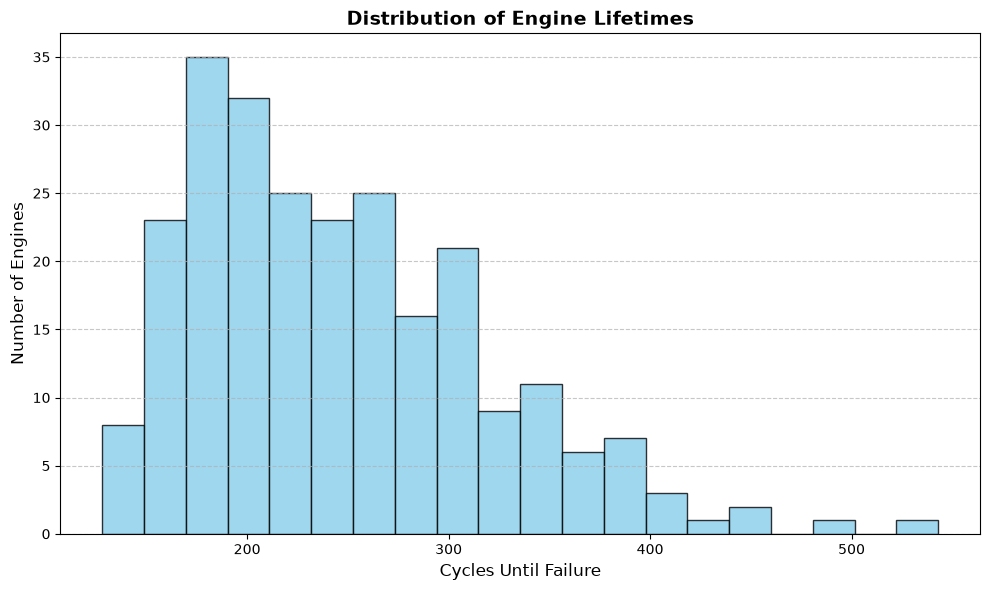

In [9]:
os.makedirs("../figures", exist_ok=True)
plt.figure(figsize=(10, 6))

# Added 'edgecolor' to define bin borders and 'alpha' for better transparency
plt.hist(engine_lifetimes, bins=20, color='skyblue', edgecolor='black', alpha=0.8)

# Added grid lines for easier y-axis reading
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.title("Distribution of Engine Lifetimes", fontsize=14, fontweight='bold')
plt.xlabel("Cycles Until Failure", fontsize=12)
plt.ylabel("Number of Engines", fontsize=12)

plt.tight_layout()

plt.savefig(
    "../figures/engine_lifetime_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Exploratory Data Analysis

In [10]:
max_cycles = train_df.groupby("engine_id")["cycle"].transform("max")
train_df["RUL"] = max_cycles - train_df["cycle"]
print(f"Min RUL: {train_df['RUL'].min()}, Max RUL: {train_df['RUL'].max()}, Mean RUL: {train_df['RUL'].mean():.2f}")

Min RUL: 0, Max RUL: 542, Mean RUL: 133.31


In [11]:
stats = train_df.describe().T

constant_cols = train_df.columns[train_df.nunique() == 1]
low_variance = stats[stats["std"] < 1]

print(constant_cols.tolist())
print(low_variance)

[]
                count      mean       std     min     25%     50%     75%  \
op_setting_2  61249.0  0.571347  0.310703  0.0000  0.2507  0.7000  0.8400   
sensor_10     61249.0  1.096445  0.127681  0.9300  1.0200  1.0300  1.2600   
sensor_15     61249.0  9.285604  0.750374  8.1757  8.6480  9.2556  9.3658   
sensor_16     61249.0  0.023252  0.004685  0.0200  0.0200  0.0200  0.0300   

                  max  
op_setting_2   0.8420  
sensor_10      1.3200  
sensor_15     11.0663  
sensor_16      0.0300  


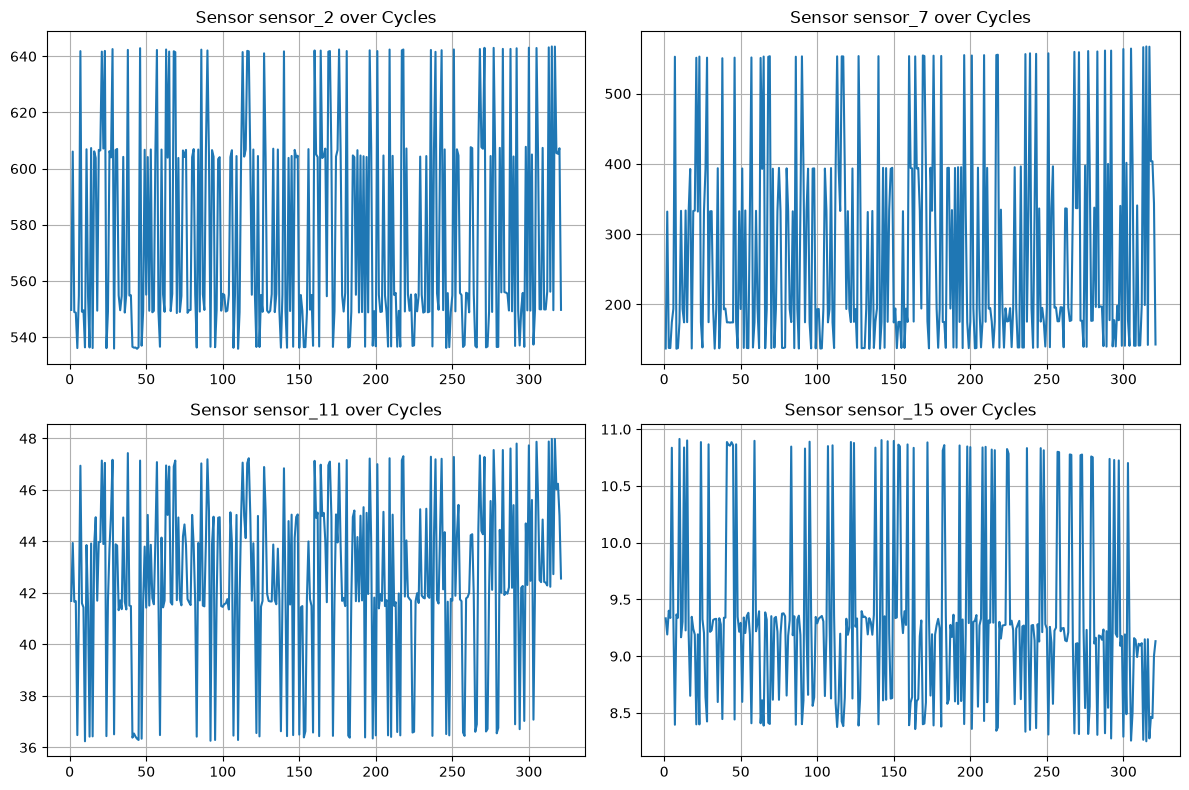

In [12]:
engine_1 = train_df[train_df['engine_id'] == 1]
sensors = ['sensor_2', 'sensor_7', 'sensor_11', 'sensor_15']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, ax in enumerate(axes.flatten()):
    ax.plot(engine_1['cycle'], engine_1[sensors[i]])
    ax.set_title(f"Sensor {sensors[i]} over Cycles")
    ax.grid(True)
plt.tight_layout()

plt.tight_layout()
plt.savefig(
    "../figures/sensor_degradation_examples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

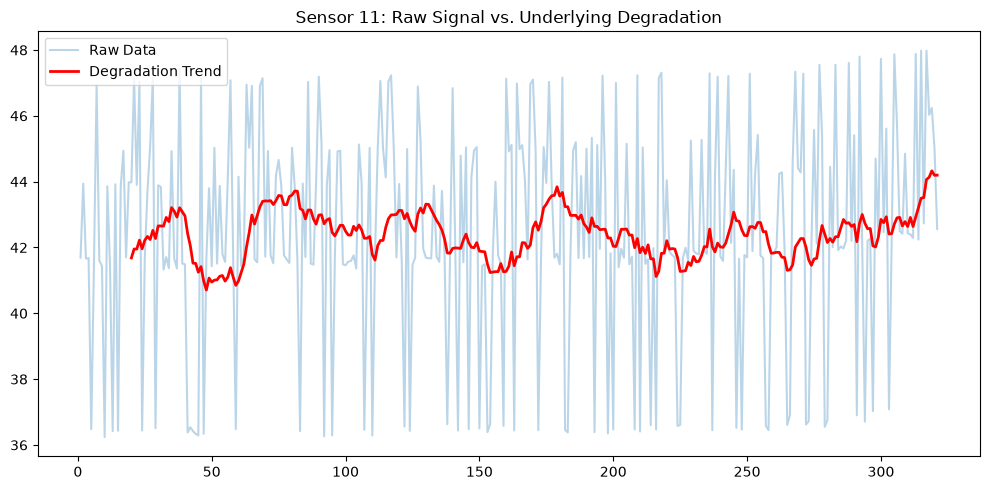

In [13]:
window_size = 20 # Adjust this to see more/less smoothing
engine_1_smooth = engine_1['sensor_11'].rolling(window=window_size).mean()

plt.figure(figsize=(10, 5))
plt.plot(engine_1['cycle'], engine_1['sensor_11'], alpha=0.3, label='Raw Data')
plt.plot(engine_1['cycle'], engine_1_smooth, color='red', linewidth=2, label='Degradation Trend')
plt.title("Sensor 11: Raw Signal vs. Underlying Degradation")
plt.legend()
plt.tight_layout()
plt.savefig(
    "../figures/sensor11_degradation_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

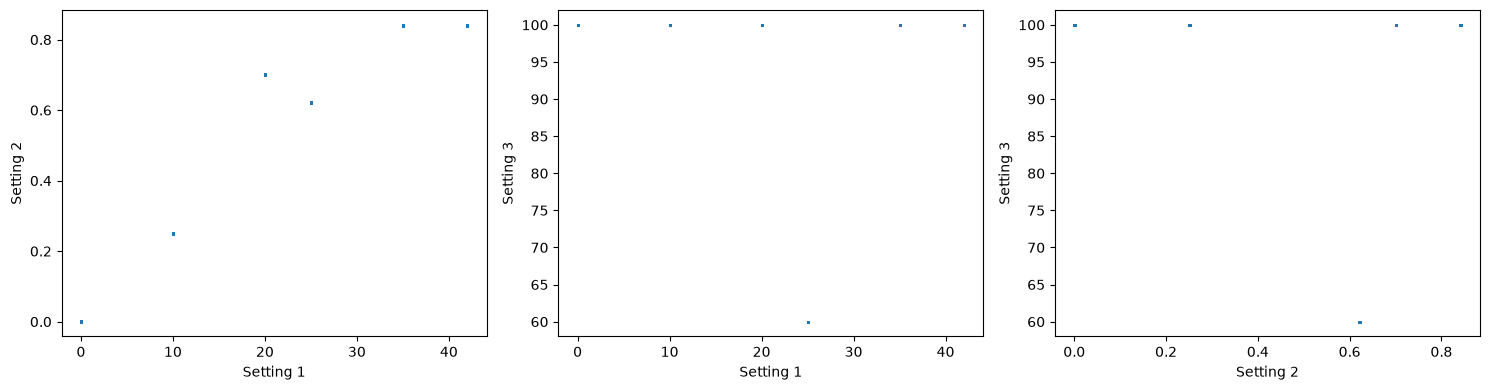

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(train_df['op_setting_1'], train_df['op_setting_2'], s=1, alpha=0.1)
axes[0].set_xlabel('Setting 1'); axes[0].set_ylabel('Setting 2')

axes[1].scatter(train_df['op_setting_1'], train_df['op_setting_3'], s=1, alpha=0.1)
axes[1].set_xlabel('Setting 1'); axes[1].set_ylabel('Setting 3')

axes[2].scatter(train_df['op_setting_2'], train_df['op_setting_3'], s=1, alpha=0.1)
axes[2].set_xlabel('Setting 2'); axes[2].set_ylabel('Setting 3')

plt.tight_layout()
plt.savefig(
    "../figures/operating_regimes.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [15]:
sensor_correlations = (
    train_df
    .corr(numeric_only=True)["RUL"]
    .sort_values()
)

print(sensor_correlations)

cycle          -0.610620
sensor_14      -0.078126
sensor_11      -0.056639
sensor_16      -0.053804
sensor_4       -0.045881
sensor_17      -0.032939
sensor_3       -0.032924
sensor_9       -0.024727
sensor_10      -0.008924
sensor_2       -0.004443
sensor_15      -0.003957
engine_id      -0.003656
op_setting_1   -0.002380
op_setting_2   -0.002280
sensor_12      -0.001639
sensor_7       -0.001429
sensor_6        0.001349
sensor_13       0.001501
sensor_5        0.001679
sensor_1        0.001889
sensor_8        0.002086
sensor_19       0.002303
op_setting_3    0.002303
sensor_18       0.002765
sensor_21       0.002791
sensor_20       0.002812
RUL             1.000000
Name: RUL, dtype: float64


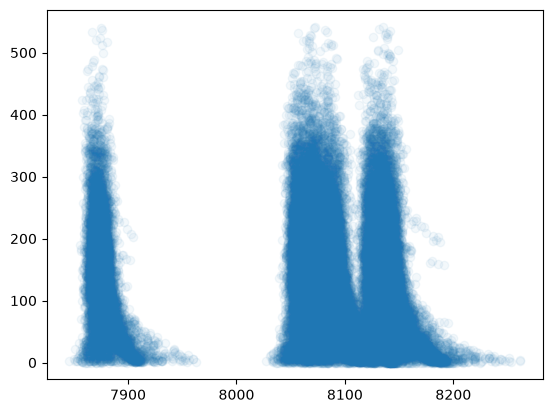

In [16]:
plt.scatter(
    train_df["sensor_14"],
    train_df["RUL"],
    alpha=0.05
)

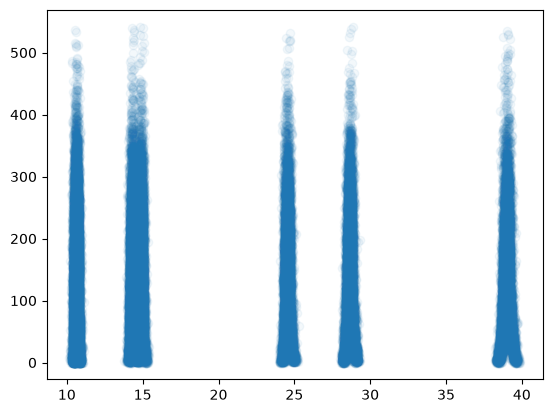

In [17]:
plt.scatter(
    train_df["sensor_20"],
    train_df["RUL"],
    alpha=0.05
)

## Visual Degradation Analysis

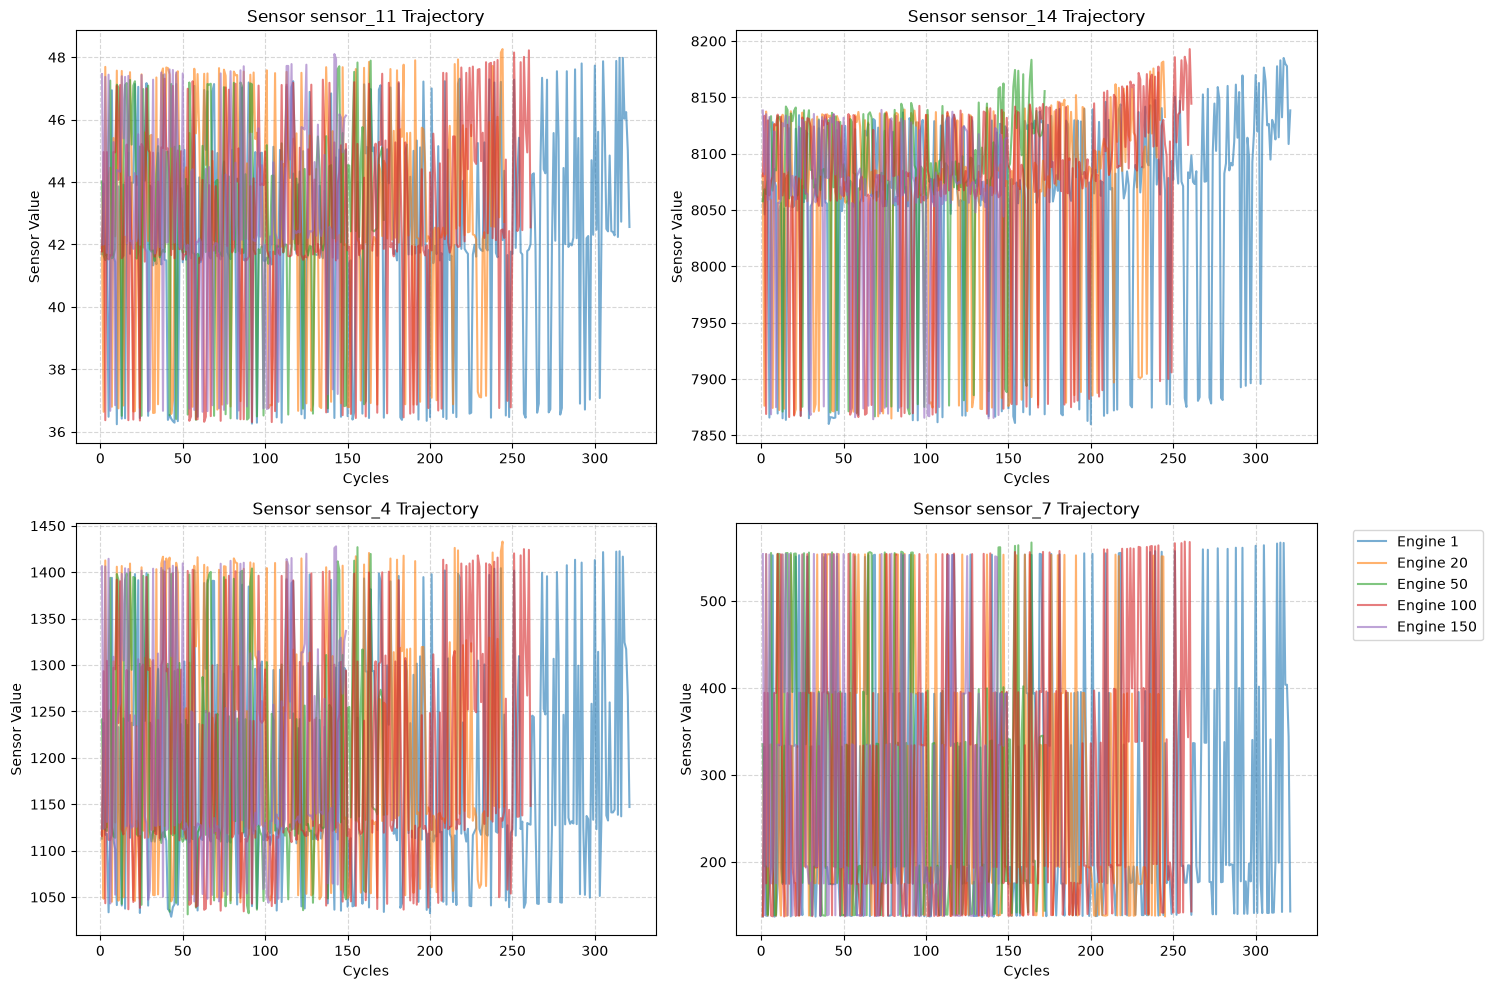

In [18]:
sample_engines = [1, 20, 50, 100, 150]

sensors_to_plot = ['sensor_11', 'sensor_14', 'sensor_4', 'sensor_7']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for ax, sensor in zip(axes.flatten(), sensors_to_plot):
    for engine in sample_engines:
        subset = train_df[train_df['engine_id'] == engine]
        ax.plot(subset['cycle'], subset[sensor], alpha=0.6, label=f"Engine {engine}")
    
    ax.set_title(f"Sensor {sensor} Trajectory")
    ax.set_xlabel("Cycles")
    ax.set_ylabel("Sensor Value")
    ax.grid(True, linestyle='--', alpha=0.5)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Feature Engineering

In [19]:
features = ['sensor_11', 'sensor_14']

for sensor in features:
    grouped = train_df.groupby('engine_id')[sensor]
    
    train_df[f'{sensor}_roll_mean_5'] = grouped.rolling(window=5).mean().reset_index(0, drop=True)
    train_df[f'{sensor}_roll_std_5'] = grouped.rolling(window=5).std().reset_index(0, drop=True)
    
    # Lags (1 and 5 cycles)
    train_df[f'{sensor}_lag_1'] = grouped.shift(1)
    train_df[f'{sensor}_lag_5'] = grouped.shift(5)
    
    # Delta (difference over 5 cycles)
    train_df[f'{sensor}_delta_5'] = grouped.diff(periods=5)

train_df = train_df.dropna()

In [20]:
def nasa_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    d = y_pred - y_true

    score = np.where(d < 0, 
                     np.exp(-d / 13.0) - 1.0, 
                     np.exp(d / 10.0) - 1.0)
    
    return np.sum(score)

In [21]:
from sklearn.metrics import make_scorer
nasa_scorer = make_scorer(nasa_score, greater_is_better=False)

In [22]:
MAX_RUL = 125
train_df["RUL_clipped"] = train_df["RUL"].clip(upper=MAX_RUL)
y = train_df["RUL_clipped"]

In [23]:
# Feature Matrix
drop_cols = [
    "engine_id",
    "RUL",
    "RUL_clipped"
]

X = train_df.drop(columns=drop_cols)
y = train_df["RUL_clipped"]
groups = train_df["engine_id"]

## Validation Strategy

In [24]:
# Cross Validation
from sklearn.model_selection import GroupKFold

cv = GroupKFold(n_splits=5)

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(model, X, y, groups, cv, scale = False):
    fold_results = []    
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y, groups = groups)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # Build pipeline with optional scaling
        if scale:
            pipeline = Pipeline([('scaler', StandardScaler()), ('model', model)])
        else:
            pipeline = Pipeline([('model', model)])
            
        # Train and Predict
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_val)
        
        # Calculate Metrics
        results = {
            "Fold": fold,
            "MAE": mean_absolute_error(y_val, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_val, y_pred)),
            "R2": r2_score(y_val, y_pred),
            "NASA": nasa_score(y_val, y_pred)
        }
        fold_results.append(results)
    
    # Create DataFrame and Summary Statistics
    results_df = pd.DataFrame(fold_results)
    summary = {f"{col}_mean": results_df[col].mean() for col in ["MAE", "RMSE", "R2", "NASA"]}
    summary.update({f"{col}_std": results_df[col].std() for col in ["MAE", "RMSE", "R2", "NASA"]})
    
    return {
    "fold_results": results_df,
    "summary": summary
}

In [26]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GroupKFold

cv = GroupKFold(n_splits=5)

# Groups for GroupKFold
groups = train_df['engine_id']

y = train_df['RUL_clipped']

print("Number of features:", X.shape[1])
print("Target:", y.name)

model_configs = [
    ("LinearRegression",
     LinearRegression(),
     True),

    ("Ridge",
     Ridge(random_state=42),
     True),

    ("RandomForestRegressor",
     RandomForestRegressor(
         n_estimators=200,
         random_state=42,
         n_jobs=-1
     ),
     False),

    ("GradientBoostingRegressor",
     GradientBoostingRegressor(
         random_state=42
     ),
     False),

    ("HistGradientBoostingRegressor",
     HistGradientBoostingRegressor(
         random_state=42
     ),
     False),

    ("XGBRegressor",
     XGBRegressor(
         random_state=42,
         n_estimators=300,
         learning_rate=0.05,
         max_depth=6,
         subsample=0.8,
         colsample_bytree=0.8,
         objective='reg:squarederror',
         n_jobs=-1
     ),
     False)
]

all_results = {}

for model_name, model, should_scale in model_configs:
    print(f"\nEvaluating {model_name}...")
    
    full_output = evaluate_model(
        model=model,
        X=X,
        y=y,
        groups=groups,
        cv=cv,
        scale=should_scale
    )
    
    all_results[model_name] = full_output['summary']


Number of features: 35
Target: RUL_clipped

Evaluating LinearRegression...

Evaluating Ridge...

Evaluating RandomForestRegressor...

Evaluating GradientBoostingRegressor...

Evaluating HistGradientBoostingRegressor...

Evaluating XGBRegressor...


In [27]:
comparison_table = pd.DataFrame.from_dict(all_results, orient='index')

# Select the desired columns for your final report
final_report = comparison_table[['MAE_mean', 'RMSE_mean', 'R2_mean', 'NASA_mean']]
final_report.columns = ['MAE', 'RMSE', 'R²', 'NASA']

print("\nFinal Results:")
print(final_report.sort_values(by='NASA'))


Final Results:
                                     MAE       RMSE        R²           NASA
RandomForestRegressor          11.189209  16.750247  0.830891  126629.451468
XGBRegressor                   11.107388  16.508875  0.835717  127625.364018
HistGradientBoostingRegressor  11.300296  16.803816  0.829743  128555.559541
GradientBoostingRegressor      13.627318  18.682264  0.790263  144556.953574
LinearRegression               16.808453  21.092051  0.732755  154004.774730
Ridge                          17.519731  21.792162  0.714714  161358.314458


## Operating Regime Analysis

In [28]:
from sklearn.cluster import KMeans

op_features = [
    "op_setting_1",
    "op_setting_2",
    "op_setting_3"
]

kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

train_df["regime"] = kmeans.fit_predict(
    train_df[op_features]
)

X = train_df.drop(columns=['engine_id', 'RUL', 'RUL_clipped'])
y = train_df['RUL_clipped']
groups = train_df['engine_id']

In [29]:
print("Cluster distribution:")
print(train_df["regime"].value_counts().sort_index())

Cluster distribution:
regime
0     9043
1    15068
2     8959
3     9013
4     8924
5     8997
Name: count, dtype: int64


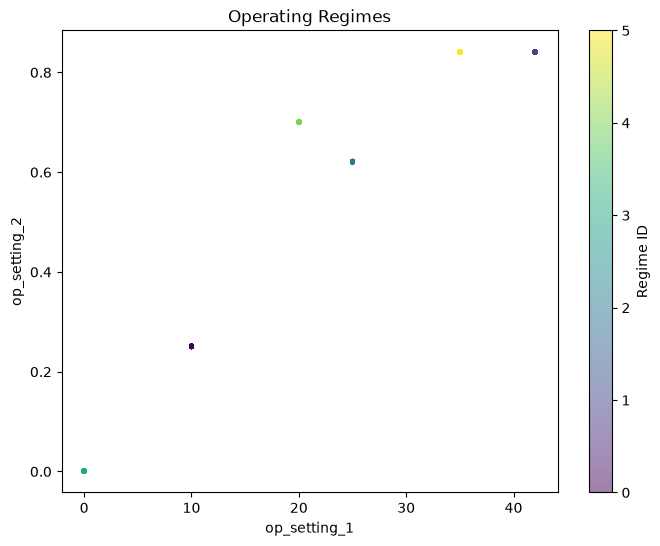

In [30]:
plt.figure(figsize=(8,6))

plt.scatter(
    train_df["op_setting_1"],
    train_df["op_setting_2"],
    c=train_df["regime"],
    s=5,
    alpha=0.5
)

plt.xlabel("op_setting_1")
plt.ylabel("op_setting_2")
plt.title("Operating Regimes")
plt.colorbar(label="Regime ID")
plt.show()

In [31]:
all_results = {}

contenders = [
    ("RandomForest", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
    ("HistGradientBoosting", HistGradientBoostingRegressor(random_state=42)),
    ("XGBoost", XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42))
]

for name, model in contenders:
    print(f"\nRetraining {name} with regime features...")
    
    # 1. Capture the full returned dictionary
    full_output = evaluate_model(model, X, y, groups, cv, scale=False)
    
    # 2. Store only the 'summary' part in your results dictionary
    all_results[name] = full_output['summary']

comparison_table = pd.DataFrame.from_dict(all_results, orient='index')


Retraining RandomForest with regime features...

Retraining HistGradientBoosting with regime features...

Retraining XGBoost with regime features...


In [32]:
# Convert the results dictionary into a clean DataFrame
comparison_df = pd.DataFrame(all_results).T

# Filter for the specific metrics we care about
# We keep the mean metrics to compare overall performance
cols_to_show = ["MAE_mean", "RMSE_mean", "NASA_mean"]
comparison_df = comparison_df[cols_to_show]

# Rename for readability
comparison_df.columns = ["MAE", "RMSE", "NASA Score"]

# Sort by NASA Score to see which model is safest
print(comparison_df.sort_values(by="NASA Score"))

                            MAE       RMSE     NASA Score
RandomForest          11.189536  16.747389  126680.871918
XGBoost               11.175135  16.650995  130378.273404
HistGradientBoosting  11.306048  16.799755  130833.841095


## Hyperparameter Tuning

In [33]:
from sklearn.model_selection import RandomizedSearchCV

rf_param_dist = {
    'n_estimators': [200, 400],
    'max_depth': [20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 0.5]
}

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=1
)

cv_tuning = GroupKFold(n_splits=3)

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_dist,
    n_iter=10,
    scoring= nasa_scorer,
    cv=cv_tuning,
    random_state=42,
    n_jobs=-1,
    verbose=3
)
rf_search.fit(
    X,
    y,
    groups=groups
)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [20, None], 'max_features': ['sqrt', 0.5], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",make_scorer(n...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",GroupKFold(n_...shuffle=False)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refi

In [34]:
print("Best Parameters:")
print(rf_search.best_params_)

print("\nBest CV NASA Score:")
print(-rf_search.best_score_)

Best Parameters:
{'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}

Best CV NASA Score:
209350.5941058906


In [35]:
xgb_param_dist = {
    "n_estimators": [200, 300, 500],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 3, 5]
}


xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=1
)

cv_tuning = GroupKFold(n_splits=3)

# 4. Configure the RandomizedSearchCV
xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_param_dist,
    n_iter=15,
    scoring= nasa_scorer,
    cv=cv_tuning,
    random_state=42,
    n_jobs=-1,  # Uses all CPU cores
    verbose=3   # To see the output as it progresses
)

# 5. Run the search
print("Starting XGBoost hyperparameter tuning...")
xgb_search.fit(
    X, 
    y, 
    groups=groups
)

Starting XGBoost hyperparameter tuning...
Fitting 3 folds for each of 15 candidates, totalling 45 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.03, 0.05, ...], 'max_depth': [4, 6, ...], 'min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",make_scorer(n...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",GroupKFold(n_...shuffle=False)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best e

In [36]:
print(f"\nBest Parameters: {xgb_search.best_params_}")
print(f"Best CV NASA Score: {-xgb_search.best_score_:.4f}")

# The best model is ready to use:
best_xgb = xgb_search.best_estimator_


Best Parameters: {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 1.0}
Best CV NASA Score: 219320.5949


In [37]:
final_rf = RandomForestRegressor(
    **rf_search.best_params_,
    random_state=42,
    n_jobs=-1
)
final_rf.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0


In [38]:
final_xgb = XGBRegressor(
    **xgb_search.best_params_,
    random_state=42,
    objective='reg:squarederror',
    n_jobs=-1
)
final_xgb.fit(X, y)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## Model Explainability

### Feature Importance

In [39]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": final_rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print(importance_df.head(15))

            feature  importance
0             cycle    0.200359
16        sensor_13    0.164095
14        sensor_11    0.071459
18        sensor_15    0.053965
7          sensor_4    0.052288
17        sensor_14    0.051883
11         sensor_8    0.033650
27  sensor_11_lag_1    0.032133
32  sensor_14_lag_1    0.030630
33  sensor_14_lag_5    0.027445
12         sensor_9    0.027004
28  sensor_11_lag_5    0.026657
6          sensor_3    0.020726
5          sensor_2    0.020080
15        sensor_12    0.019617


<Figure size 1000x800 with 0 Axes>

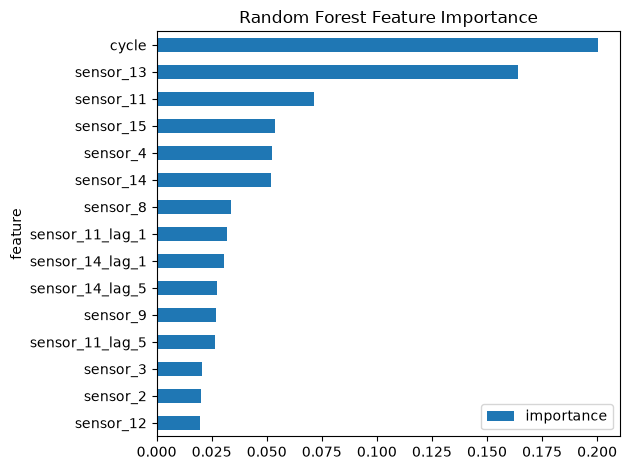

In [40]:
plt.figure(figsize=(10,8))

importance_df.head(15).sort_values(
    "importance"
).plot(
    x="feature",
    y="importance",
    kind="barh"
)

plt.title("Random Forest Feature Importance")
plt.tight_layout()

plt.savefig(
    "../figures/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Permutation Importance

In [41]:
from sklearn.inspection import permutation_importance

def get_permutation_importance(model, X, y):
    result = permutation_importance(model, X, y, n_repeats=10, random_state=42, n_jobs=-1)
    importance_df = pd.DataFrame({
        "feature": X.columns,
        "importance": result.importances_mean
    }).sort_values(by="importance", ascending=False)
    return importance_df

perm_importance = get_permutation_importance(final_xgb, X, y)
print(perm_importance.head(15))

            feature  importance
0             cycle    0.295386
16        sensor_13    0.292488
18        sensor_15    0.281268
9          sensor_6    0.246764
14        sensor_11    0.130996
7          sensor_4    0.042201
17        sensor_14    0.040594
11         sensor_8    0.025129
12         sensor_9    0.020443
27  sensor_11_lag_1    0.018874
15        sensor_12    0.015269
32  sensor_14_lag_1    0.010490
28  sensor_11_lag_5    0.009142
6          sensor_3    0.009137
10         sensor_7    0.008281


<Figure size 1000x800 with 0 Axes>

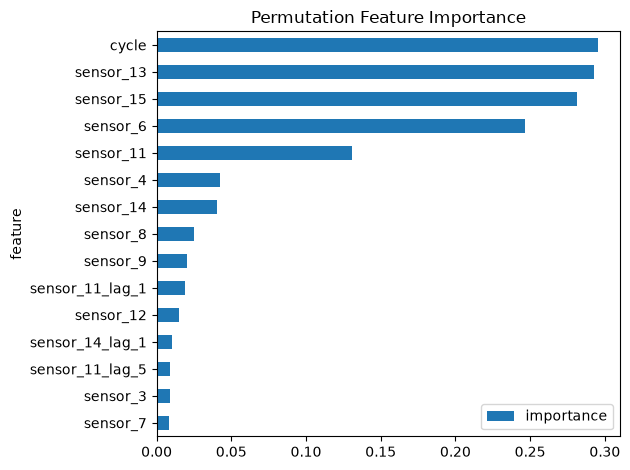

In [42]:
plt.figure(figsize=(10,8))

perm_importance.head(15).sort_values(
    "importance"
).plot(
    x="feature",
    y="importance",
    kind="barh"
)

plt.title("Permutation Feature Importance")
plt.tight_layout()

plt.savefig(
    "../figures/permutation_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### SHAP Analysis

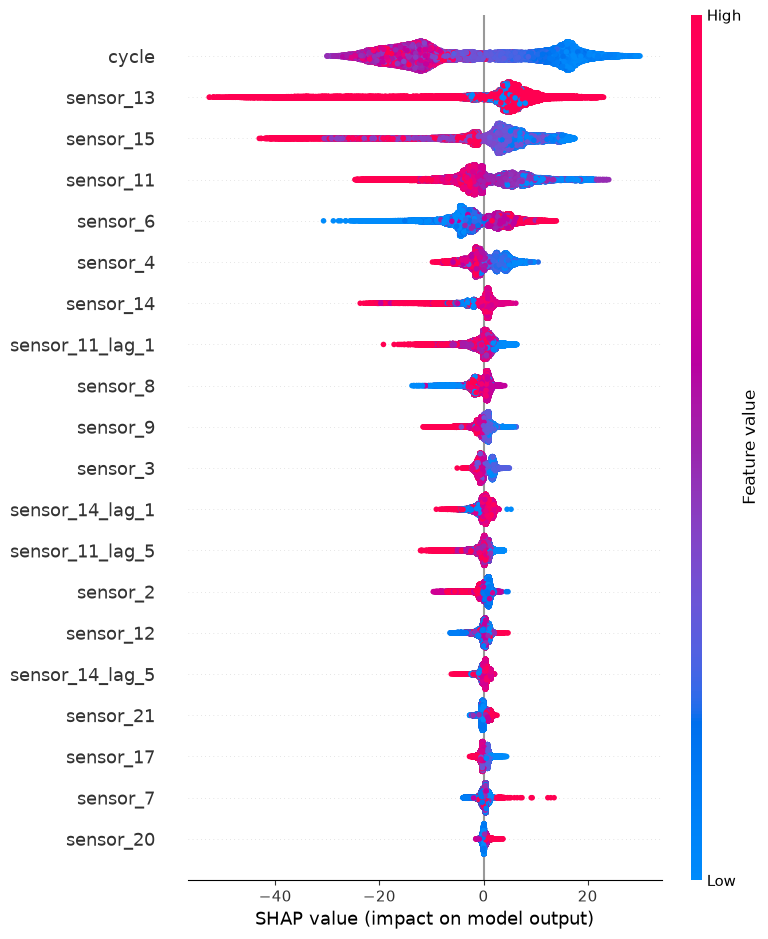

In [43]:
import shap

explainer = shap.TreeExplainer(final_xgb)
shap_values = explainer.shap_values(X)

shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0,:], X.iloc[0,:])

# Global importance plot
shap.summary_plot(shap_values, X)

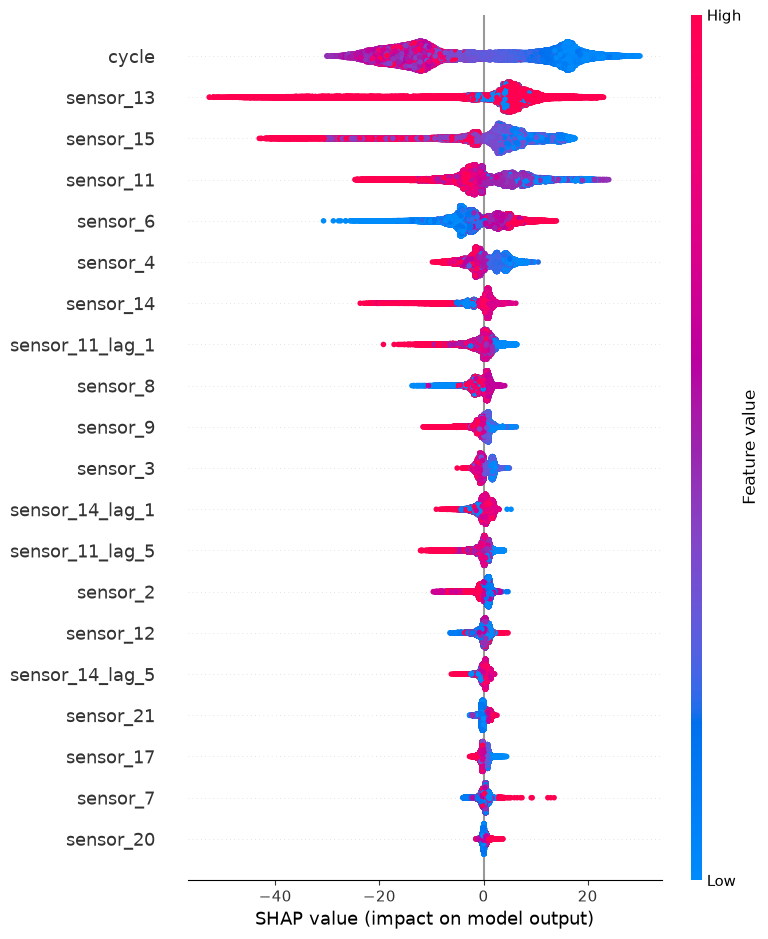

In [44]:
shap.summary_plot(
    shap_values,
    X,
    show=False
)

plt.tight_layout()

plt.savefig(
    "../figures/shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
test_df["regime"] = kmeans.predict(
    test_df[op_features]
)

In [46]:
for sensor in features:

    grouped = test_df.groupby("engine_id")[sensor]

    test_df[f"{sensor}_roll_mean_5"] = (
        grouped
        .rolling(window=5)
        .mean()
        .reset_index(level=0, drop=True)
    )

    test_df[f"{sensor}_roll_std_5"] = (
        grouped
        .rolling(window=5)
        .std()
        .reset_index(level=0, drop=True)
    )

    test_df[f"{sensor}_lag_1"] = grouped.shift(1)

    test_df[f"{sensor}_lag_5"] = grouped.shift(5)

    test_df[f"{sensor}_delta_5"] = grouped.diff(5)

cols_to_fill = [c for c in test_df.columns if c != "engine_id"]
test_df[cols_to_fill] = test_df.groupby("engine_id")[cols_to_fill].bfill()

In [47]:
test_last = (
    test_df
    .groupby("engine_id")
    .tail(1)
    .copy()
)

In [48]:
X_test = test_last.drop(
    columns=[
        "engine_id"
    ]
)

print(X_test.shape)

(248, 36)


In [49]:
X_test = X_test[X.columns]

rf_predictions = final_rf.predict(X_test)


In [50]:
xgb_predictions = final_xgb.predict(X_test)

In [51]:
rul_truth = pd.read_csv(
    "../data/RUL_FD004.txt",
    sep=r"\s+",
    header=None
)

In [52]:
rul_truth.columns = ["additional_rul"]

rul_truth["engine_id"] = np.arange(
    1,
    len(rul_truth) + 1
)

In [53]:
print("Test engines:", test_df["engine_id"].nunique())
print("RUL entries:", len(rul_truth))

Test engines: 248
RUL entries: 248


In [54]:
last_cycle = (
    test_df.groupby("engine_id")["cycle"]
    .max()
    .reset_index()
)

last_cycle.columns = [
    "engine_id",
    "observed_cycle"
]

truth = last_cycle.merge(
    rul_truth,
    on="engine_id"
)

truth["true_rul"] = truth["additional_rul"]

In [55]:
y_test = truth["true_rul"].values

In [56]:
print("Random Forest Results")
print(
    "MAE:",
    mean_absolute_error(y_test, rf_predictions)
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            rf_predictions
        )
    )
)

print(
    "R2:",
    r2_score(
        y_test,
        rf_predictions
    )
)

print(
    "NASA:",
    nasa_score(
        y_test,
        rf_predictions
    )
)

Random Forest Results
MAE: 22.304495967741936
RMSE: 29.784234906942558
R2: 0.7015986573420228
NASA: 7026.365025196934


In [57]:
print("XGBoost Results")
print(
    "MAE:",
    mean_absolute_error(
        y_test,
        xgb_predictions
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            xgb_predictions
        )
    )
)

print(
    "R2:",
    r2_score(
        y_test,
        xgb_predictions
    )
)

print(
    "NASA:",
    nasa_score(
        y_test,
        xgb_predictions
    )
)

XGBoost Results
MAE: 21.005781173706055
RMSE: 28.405204661390293
R2: 0.7285913228988647
NASA: 5553.1184752029985


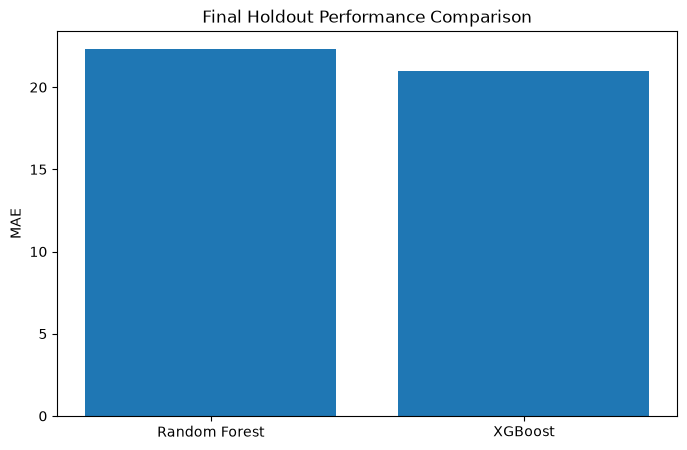

In [58]:
plt.figure(figsize=(8,5))

models = ['Random Forest', 'XGBoost']
mae = [
    mean_absolute_error(y_test, rf_predictions),
    mean_absolute_error(y_test, xgb_predictions)
]

plt.bar(models, mae)
plt.ylabel("MAE")
plt.title("Final Holdout Performance Comparison")

plt.savefig(
    "../figures/mae_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


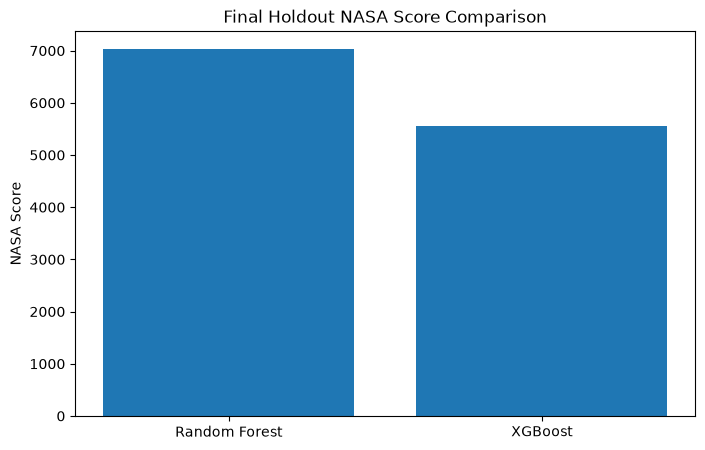

In [60]:
plt.figure(figsize=(8,5))

models = ['Random Forest', 'XGBoost']

nasa_scores = [
    nasa_score(y_test, rf_predictions),
    nasa_score(y_test, xgb_predictions)
]

plt.bar(models, nasa_scores)

plt.ylabel("NASA Score")
plt.title("Final Holdout NASA Score Comparison")

plt.savefig(
    "../figures/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Model Saving and Persistence

In [61]:
os.makedirs("../models", exist_ok=True)

joblib.dump(final_xgb, "../models/xgb_rul_model.pkl")
joblib.dump(kmeans, "../models/regime_kmeans.pkl")
joblib.dump(list(X.columns), "../models/feature_order.pkl")


['../models/feature_order.pkl']

In [62]:
op_features = [
    "op_setting_1",
    "op_setting_2",
    "op_setting_3"
]

important_sensors = [
    "sensor_11",
    "sensor_14"
]


def predict_engine_rul(engine_df):

    model = joblib.load("../models/xgb_rul_model.pkl")
    kmeans = joblib.load("../models/regime_kmeans.pkl")
    feature_order = joblib.load("../models/feature_order.pkl")

    # Operating regime assignment
    engine_df["regime"] = kmeans.predict(
        engine_df[op_features]
    )

    # Feature engineering
    for sensor in important_sensors:

        engine_df[f"{sensor}_roll_mean_5"] = (
            engine_df[sensor]
            .rolling(5)
            .mean()
        )

        engine_df[f"{sensor}_roll_std_5"] = (
            engine_df[sensor]
            .rolling(5)
            .std()
        )

        engine_df[f"{sensor}_lag_1"] = (
            engine_df[sensor]
            .shift(1)
        )

        engine_df[f"{sensor}_lag_5"] = (
            engine_df[sensor]
            .shift(5)
        )

        engine_df[f"{sensor}_delta_5"] = (
            engine_df[sensor]
            .diff(5)
        )

    engine_df = engine_df.bfill()

    X_inference = engine_df.reindex(
        columns=feature_order
    )

    predictions = model.predict(X_inference)

    return predictions[-1]

In [63]:
engine_1 = test_df[
    test_df["engine_id"] == 1
].copy()

predicted_rul = predict_engine_rul(engine_1)

print(
    f"Predicted RUL: {predicted_rul:.2f} cycles"
)

Predicted RUL: 46.43 cycles


In [64]:
actual_rul = rul_truth.iloc[0, 0]

print(
    f"Actual RUL: {actual_rul} cycles" 
)

Actual RUL: 22 cycles


In [65]:
error = xgb_predictions - y_test

print("Mean Error:", error.mean())
print("Median Error:", np.median(error))

print("Overestimations:", np.sum(error > 0))
print("Underestimations:", np.sum(error < 0))

Mean Error: -7.4085906599798514
Median Error: -1.3620038032531738
Overestimations: 116
Underestimations: 132


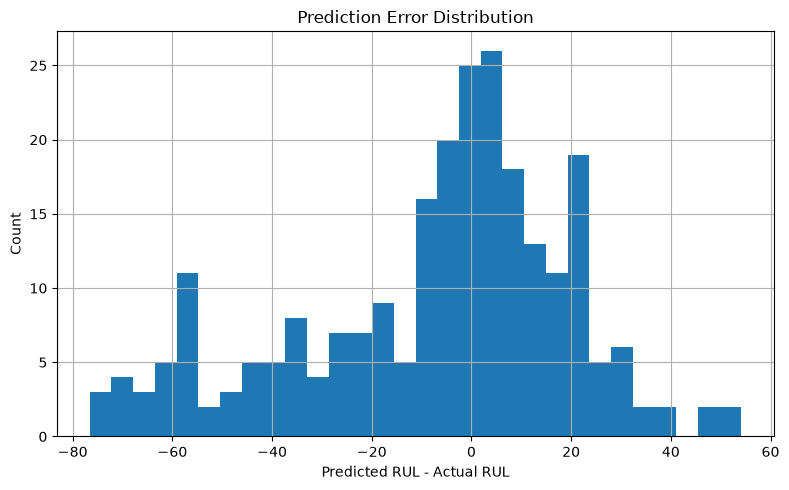

In [66]:

plt.figure(figsize=(8,5))
plt.hist(error, bins=30)

plt.title("Prediction Error Distribution")
plt.xlabel("Predicted RUL - Actual RUL")
plt.ylabel("Count")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../figures/error_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [67]:
prediction_report = pd.DataFrame({
    "engine_id": test_last["engine_id"],
    "actual_rul": y_test,
    "predicted_rul": xgb_predictions,
    "prediction_error": xgb_predictions - y_test
})

prediction_report["absolute_error"] = (
    prediction_report["prediction_error"].abs()
)

prediction_report.head(10)

,engine_id,actual_rul,predicted_rul,prediction_error,absolute_error
229,1,22,46.425613,24.425613,24.425613
382,2,39,57.367134,18.367134,18.367134
523,3,107,75.121361,-31.878639,31.878639
731,4,75,111.059311,36.059311,36.059311
782,5,149,119.830765,-29.169235,29.169235
928,6,78,107.545036,29.545036,29.545036
982,7,94,114.152840,20.152840,20.152840
1230,8,14,15.186489,1.186489,1.186489
1514,9,99,95.009613,-3.990387,3.990387
1537,10,162,125.236015,-36.763985,36.763985


In [68]:
prediction_report.to_csv(
    "../reports/prediction_report.csv",
    index=False
)

## Maintenance Risk Categorization

In [69]:
risk_df = prediction_report.copy()

risk_df["risk_level"] = pd.cut(
    risk_df["predicted_rul"],
    bins=[-1, 20, 50, 125],
    labels=[
        "Critical",
        "Warning",
        "Healthy"
    ]
)

risk_df[
    ["engine_id",
     "predicted_rul",
     "risk_level"]
].head(10)

,engine_id,predicted_rul,risk_level
229,1,46.425613,Warning
382,2,57.367134,Healthy
523,3,75.121361,Healthy
731,4,111.059311,Healthy
782,5,119.830765,Healthy
928,6,107.545036,Healthy
982,7,114.152840,Healthy
1230,8,15.186489,Critical
1514,9,95.009613,Healthy
1537,10,125.236015,NaN


In [70]:
risk_df["risk_level"].value_counts()

risk_level
Healthy     164
Warning      40
Critical     33
Name: count, dtype: int64

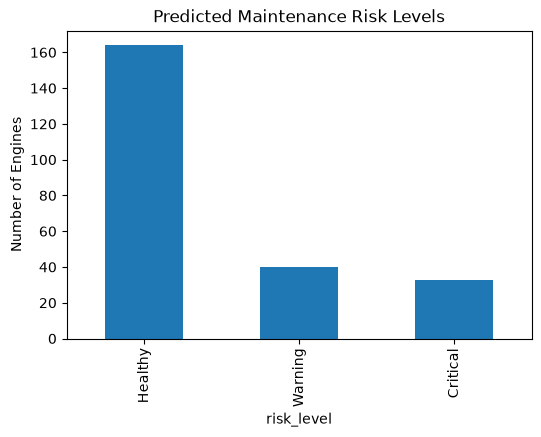

In [71]:
plt.figure(figsize=(6,4))

risk_df["risk_level"].value_counts().plot(
    kind="bar"
)

plt.title("Predicted Maintenance Risk Levels")
plt.ylabel("Number of Engines")

plt.savefig(
    "../figures/risk_levels.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

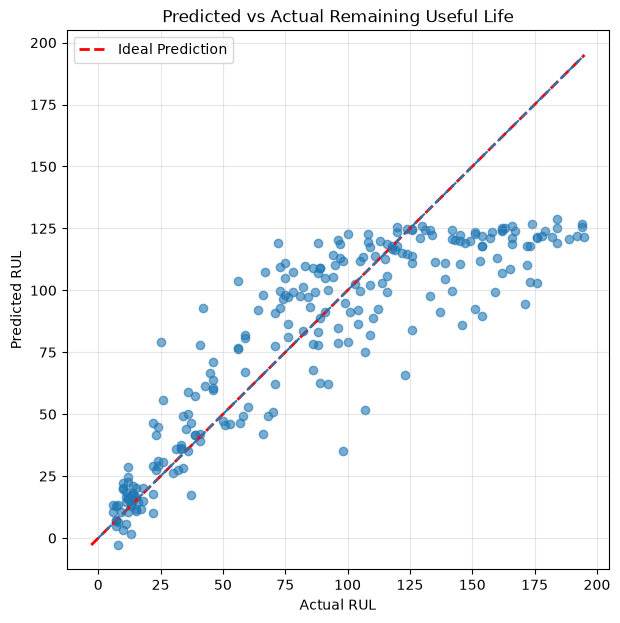

In [72]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, xgb_predictions, alpha=0.6)

plt.grid(alpha=0.3)

lims = [
    min(y_test.min(), xgb_predictions.min()),
    max(y_test.max(), xgb_predictions.max())
]

plt.plot(
    lims,
    lims,
    'r--',
    linewidth=2,
    label='Ideal Prediction'
)

plt.legend()

plt.plot(
    [0, max(y_test)],
    [0, max(y_test)],
    linestyle='--'
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Predicted vs Actual Remaining Useful Life")

plt.savefig(
    "../figures/predicted_vs_actual.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [73]:
final_results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "MAE": [
        mean_absolute_error(y_test, rf_predictions),
        mean_absolute_error(y_test, xgb_predictions)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, rf_predictions)),
        np.sqrt(mean_squared_error(y_test, xgb_predictions))
    ],
    "R2": [
        r2_score(y_test, rf_predictions),
        r2_score(y_test, xgb_predictions)
    ],
    "NASA Score": [
        nasa_score(y_test, rf_predictions),
        nasa_score(y_test, xgb_predictions)
    ]
})

print(final_results)


           Model        MAE       RMSE        R2   NASA Score
0  Random Forest  22.304496  29.784235  0.701599  7026.365025
1        XGBoost  21.005781  28.405205  0.728591  5553.118475


In [74]:
os.makedirs("../reports", exist_ok=True)

with pd.ExcelWriter("../reports/feature_importance_report.xlsx") as writer:
    importance_df.to_excel(writer, sheet_name="Feature Importance (RF)", index=False)
    perm_importance.to_excel(writer, sheet_name="Permutation Importance (XGB)", index=False)

In [75]:
predictions = []

for engine_id in test_df["engine_id"].unique():

    engine_history = test_df[
        test_df["engine_id"] == engine_id
    ].copy()

    pred = predict_engine_rul(engine_history)

    predictions.append({
        "engine_id": engine_id,
        "predicted_rul": pred
    })

predictions_df = pd.DataFrame(predictions)

print(predictions_df.head())

   engine_id  predicted_rul
0          1      46.425613
1          2      57.367134
2          3      75.121361
3          4     111.059311
4          5     119.830765


In [76]:
def classify_risk(rul):

    if rul < 15:
        return "Critical"

    elif rul < 40:
        return "Warning"

    else:
        return "Healthy"

In [77]:
predictions_df["risk_level"] = (
    predictions_df["predicted_rul"]
    .apply(classify_risk)
)

print(
    predictions_df.head()
)

   engine_id  predicted_rul risk_level
0          1      46.425613    Healthy
1          2      57.367134    Healthy
2          3      75.121361    Healthy
3          4     111.059311    Healthy
4          5     119.830765    Healthy


## Conclusions

This project developed an end-to-end machine learning pipeline for Remaining Useful Life prediction using the challenging NASA CMAPSS FD004 turbofan degradation dataset.

Several important findings emerged from the study:

* The XGBoost model achieved the strongest performance on the official NASA holdout dataset, obtaining the lowest MAE, RMSE, and NASA score among all evaluated approaches.

* Group-aware cross-validation using engine identifiers proved essential for obtaining realistic performance estimates and preventing temporal leakage that would otherwise lead to overly optimistic results.

* Operating regime clustering using KMeans successfully captured variations in engine operating conditions and improved the robustness of the predictive models under regime-switching behavior.

* Temporal feature engineering, including rolling statistics, lag features, and degradation trends, provided substantially more predictive power than raw sensor measurements alone.

* Classical machine learning methods demonstrated competitive performance on the FD004 benchmark despite the absence of sequence-based deep learning architectures such as LSTMs, GRUs, or Transformers.

* The inclusion of explainability techniques, including feature importance analysis, permutation importance, and SHAP values, improved model transparency and provided insight into the physical degradation mechanisms driving predictions.

Overall, the project demonstrates that carefully engineered features, robust validation strategies, and interpretable tree-based models can provide strong prognostic performance while maintaining lower computational complexity and higher interpretability than many deep learning alternatives.


## Future Work

Several extensions could further improve predictive performance and move the system closer to production-grade industrial deployment:

* **Sequence-based Deep Learning Models:** Investigate LSTM, GRU, and Transformer architectures capable of directly modeling long-term temporal dependencies without manual feature engineering.

* **Physics-Informed Machine Learning:** Incorporate domain knowledge and degradation physics to improve extrapolation capability and increase trustworthiness in safety-critical environments.

* **Uncertainty Quantification:** Extend the model to produce confidence intervals alongside point estimates to support risk-aware maintenance scheduling and operational decision-making.

* **Cost-Sensitive Optimization:** Optimize models using asymmetric loss functions that penalize RUL overestimation more heavily than underestimation, reflecting the true economic and safety costs of unexpected failures.

* **Online Learning and Model Updating:** Enable continuous model adaptation using newly collected sensor data to mitigate performance degradation caused by concept drift and changing operating environments.

* **Real-Time Deployment Pipeline:** Deploy the inference pipeline as a REST API or edge inference service capable of providing live Remaining Useful Life estimates from streaming telemetry data.

* **Multi-Asset Fleet Optimization:** Extend predictions from individual assets to fleet-level maintenance optimization and spare-parts planning.

* **Benchmarking Against Deep Learning Baselines:** Compare the proposed feature-engineered approach against state-of-the-art sequence models on FD004 to quantify the tradeoff between interpretability, computational cost, and predictive accuracy.
